Using device: cpu

DATASET LOADED
Samples: 5600
Total columns: 100
Number of classes: 4

ABLATION FEATURE CHECK
Mean: 25 features
Variance: 25 features
Transition: 25 features
Mean + Variance: 50 features
Mean + Transition: 50 features
Variance + Transition: 50 features
Full DMVTD: 75 features

Component counts:
Mean columns: 25
Variance columns: 25
Transition columns: 25

################################################################################
STARTING: Mean
################################################################################

EXPERIMENT: Mean
NUMBER OF FEATURES: 25

----------------------------------------------------------------------
Fold 1/5
----------------------------------------------------------------------
  SVM: acc=0.7884 | precision=0.7935 | recall=0.7884 | f1=0.7873
  KNN: acc=0.8286 | precision=0.8309 | recall=0.8286 | f1=0.8284
  RF: acc=0.8741 | precision=0.8742 | recall=0.8741 | f1=0.8734
  LR: acc=0.7679 | precision=0.7694 | recall=0.7679 | f1=0.7

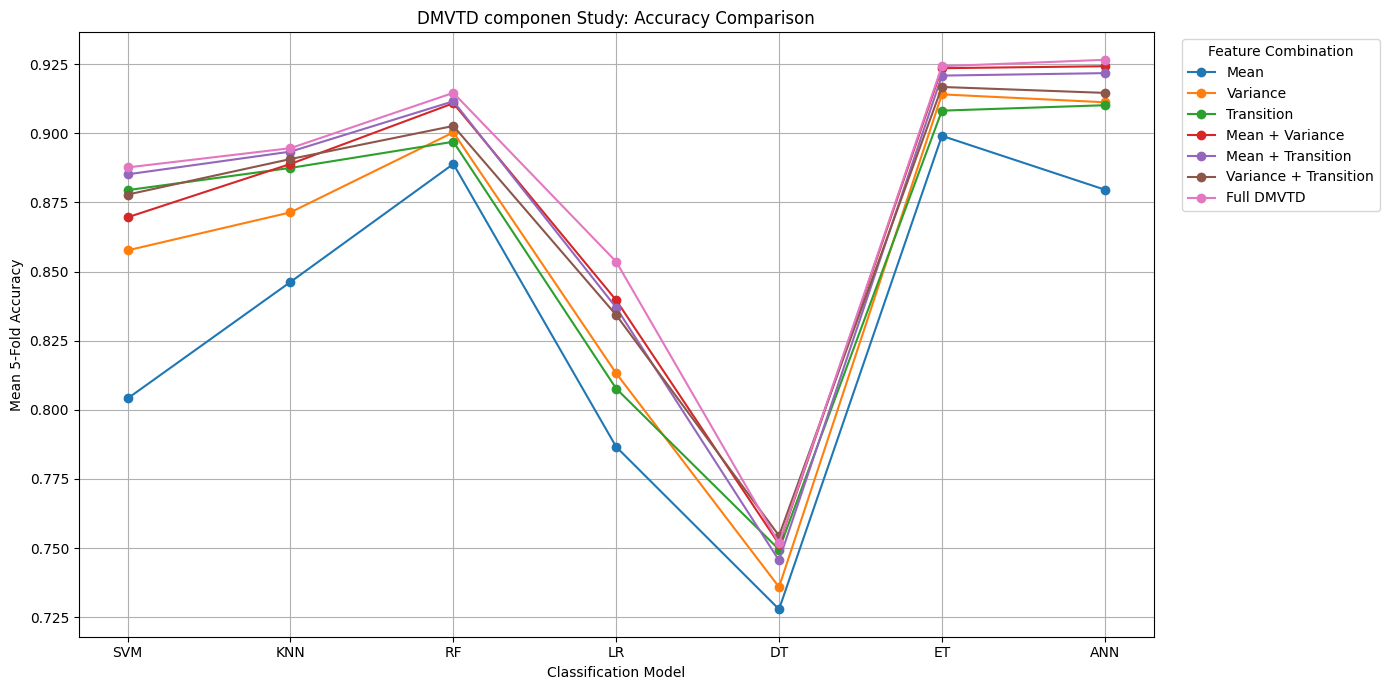

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# =====================================================
# PYTORCH IMPORTS FOR ANN
# =====================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader


# =====================================================
# SETTINGS
# =====================================================

# CHANGE THIS TO YOUR ONE DATASET
CSV_PATH = "glcm_5/brain_mri/dmvtd.csv"

N_SPLITS = 5
RANDOM_STATE = 42

# ANN SETTINGS
EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 0.001


# =====================================================
# REPRODUCIBILITY
# =====================================================

np.random.seed(RANDOM_STATE)

torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)
    torch.cuda.manual_seed_all(RANDOM_STATE)


# =====================================================
# DEVICE
# =====================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Using device: {device}")


# =====================================================
# LOAD DATA
# =====================================================

def load_data(file_path):

    df = pd.read_csv(file_path)

    # Labels
    label_encoder = LabelEncoder()

    y = label_encoder.fit_transform(
        df["label"]
    )

    # All feature columns
    X = df.drop(
        columns=["label"]
    )

    # Convert all columns to numeric
    X = X.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Replace infinity with NaN
    X = X.replace(
        [np.inf, -np.inf],
        np.nan
    )

    return X, y


# =====================================================
# SELECT DMVTD COMPONENT COLUMNS
# =====================================================

def get_ablation_features(X):

    # ---------------------------------------------
    # MEAN COLUMNS
    # ---------------------------------------------

    mean_cols = [
        col for col in X.columns
        if col.endswith("_mean")
    ]


    # ---------------------------------------------
    # VARIANCE COLUMNS
    # ---------------------------------------------

    variance_cols = [
        col for col in X.columns
        if col.endswith("_variance")
    ]


    # ---------------------------------------------
    # TRANSITION COLUMNS
    # ---------------------------------------------

    transition_cols = [
        col for col in X.columns
        if col.endswith("_transition")
    ]


    # =================================================
    # 7 ABLATION EXPERIMENTS
    # =================================================

    experiments = {

        # ---------------------------------------------
        # 1. Mean only
        # ---------------------------------------------

        "Mean":
            mean_cols,


        # ---------------------------------------------
        # 2. Variance only
        # ---------------------------------------------

        "Variance":
            variance_cols,


        # ---------------------------------------------
        # 3. Transition only
        # ---------------------------------------------

        "Transition":
            transition_cols,


        # ---------------------------------------------
        # 4. Mean + Variance
        # ---------------------------------------------

        "Mean + Variance":
            mean_cols + variance_cols,


        # ---------------------------------------------
        # 5. Mean + Transition
        # ---------------------------------------------

        "Mean + Transition":
            mean_cols + transition_cols,


        # ---------------------------------------------
        # 6. Variance + Transition
        # ---------------------------------------------

        "Variance + Transition":
            variance_cols + transition_cols,


        # ---------------------------------------------
        # 7. Full DMVTD
        # Mean + Variance + Transition
        # ---------------------------------------------

        "Full DMVTD":
            mean_cols + variance_cols + transition_cols
    }


    # =================================================
    # PRINT FEATURE COUNTS
    # =================================================

    print("\n" + "=" * 70)
    print("ABLATION FEATURE CHECK")
    print("=" * 70)

    for name, cols in experiments.items():

        print(
            f"{name}: {len(cols)} features"
        )


    # =================================================
    # CHECK EXPECTED NUMBER OF FEATURES
    # =================================================

    print("\nComponent counts:")
    print(f"Mean columns: {len(mean_cols)}")
    print(f"Variance columns: {len(variance_cols)}")
    print(f"Transition columns: {len(transition_cols)}")


    # Your expected structure:
    # 5 distances × 5 GLCM features = 25 columns
    # for each component

    assert len(mean_cols) == 25, (
        f"Expected 25 mean columns, found {len(mean_cols)}"
    )

    assert len(variance_cols) == 25, (
        f"Expected 25 variance columns, found {len(variance_cols)}"
    )

    assert len(transition_cols) == 25, (
        f"Expected 25 transition columns, "
        f"found {len(transition_cols)}"
    )


    return experiments


# =====================================================
# ANN MODEL
# =====================================================

class ANN(nn.Module):

    def __init__(
        self,
        input_size,
        num_classes
    ):

        super().__init__()

        self.network = nn.Sequential(

            # Input Layer
            nn.Linear(
                input_size,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.30),


            # Hidden Layer 1
            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),


            # Hidden Layer 2
            nn.Linear(
                64,
                32
            ),

            nn.ReLU(),


            # Output Layer
            nn.Linear(
                32,
                num_classes
            )
        )


    def forward(self, x):

        return self.network(x)


# =====================================================
# TRAIN ANN FOR ONE CV FOLD
# =====================================================

def train_ann(
    X_train,
    X_test,
    y_train,
    num_classes
):

    # ---------------------------------------------
    # SET RANDOM SEED
    # ---------------------------------------------

    torch.manual_seed(
        RANDOM_STATE
    )


    # ---------------------------------------------
    # CONVERT TO TENSORS
    # ---------------------------------------------

    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    )

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.long
    )


    # ---------------------------------------------
    # CREATE TRAIN DATASET
    # ---------------------------------------------

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )


    # ---------------------------------------------
    # CREATE DATA LOADER
    # ---------------------------------------------

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True
    )


    # ---------------------------------------------
    # MODEL
    # ---------------------------------------------

    input_size = X_train.shape[1]

    model = ANN(
        input_size=input_size,
        num_classes=num_classes
    ).to(device)


    # ---------------------------------------------
    # LOSS FUNCTION
    # ---------------------------------------------

    criterion = nn.CrossEntropyLoss()


    # ---------------------------------------------
    # OPTIMIZER
    # ---------------------------------------------

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )


    # =================================================
    # TRAIN FOR 100 EPOCHS
    # =================================================

    for epoch in range(EPOCHS):

        model.train()

        epoch_loss = 0.0


        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)


            # Forward pass
            outputs = model(
                batch_X
            )


            loss = criterion(
                outputs,
                batch_y
            )


            # Backpropagation
            optimizer.zero_grad()

            loss.backward()

            optimizer.step()


            epoch_loss += loss.item()


        # Optional progress display
        if (
            (epoch + 1) % 20 == 0
            or epoch == 0
        ):

            average_loss = (
                epoch_loss /
                len(train_loader)
            )

            print(
                f"    ANN Epoch "
                f"{epoch + 1}/{EPOCHS} | "
                f"Loss: {average_loss:.6f}"
            )


    # =================================================
    # TEST ANN
    # =================================================

    model.eval()


    with torch.no_grad():

        X_test_tensor = X_test_tensor.to(
            device
        )


        outputs = model(
            X_test_tensor
        )


        _, predicted = torch.max(
            outputs,
            dim=1
        )


        y_pred = predicted.cpu().numpy()


    return y_pred


# =====================================================
# CALCULATE METRICS
# =====================================================

def calculate_metrics(
    y_true,
    y_pred
):

    acc = accuracy_score(
        y_true,
        y_pred
    )


    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )


    return (
        acc,
        precision,
        recall,
        f1
    )


# =====================================================
# SAVE ONE MODEL RESULT
# =====================================================

def save_result(
    results,
    model_name,
    y_test,
    y_pred
):

    acc, precision, recall, f1 = (
        calculate_metrics(
            y_test,
            y_pred
        )
    )


    results[model_name]["accuracy"].append(
        acc
    )

    results[model_name]["precision"].append(
        precision
    )

    results[model_name]["recall"].append(
        recall
    )

    results[model_name]["f1"].append(
        f1
    )


    print(
        f"  {model_name}: "
        f"acc={acc:.4f} | "
        f"precision={precision:.4f} | "
        f"recall={recall:.4f} | "
        f"f1={f1:.4f}"
    )


# =====================================================
# RUN ONE ABLATION EXPERIMENT
# =====================================================

def run_experiment(
    X_df,
    y,
    experiment_name,
    num_classes
):

    print("\n" + "=" * 80)
    print(
        f"EXPERIMENT: {experiment_name}"
    )
    print(
        f"NUMBER OF FEATURES: "
        f"{X_df.shape[1]}"
    )
    print("=" * 80)


    X_raw = X_df.to_numpy()


    # =================================================
    # 5-FOLD STRATIFIED CV
    # =================================================

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=RANDOM_STATE
    )


    # =================================================
    # SCIKIT-LEARN CLASSIFIERS
    # =================================================

    model_builders = {

        "SVM":
            lambda: SVC(
                kernel="rbf",
                C=1,
                gamma="scale"
            ),


        "KNN":
            lambda: KNeighborsClassifier(
                n_neighbors=5
            ),


        "RF":
            lambda: RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ),


        "LR":
            lambda: LogisticRegression(
                max_iter=500,
                random_state=RANDOM_STATE
            ),


        "DT":
            lambda: DecisionTreeClassifier(
                max_depth=5,
                random_state=RANDOM_STATE
            ),


        "ET":
            lambda: ExtraTreesClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
    }


    # =================================================
    # ALL MODEL NAMES INCLUDING ANN
    # =================================================

    model_names = list(
        model_builders.keys()
    ) + ["ANN"]


    # =================================================
    # STORE RESULTS
    # =================================================

    results = {}


    for model_name in model_names:

        results[model_name] = {

            "accuracy": [],
            "precision": [],
            "recall": [],
            "f1": []
        }


    # =================================================
    # RUN 5 FOLDS
    # =================================================

    fold_num = 0


    for train_idx, test_idx in skf.split(
        X_raw,
        y
    ):

        fold_num += 1


        print(
            "\n" +
            "-" * 70
        )

        print(
            f"Fold {fold_num}/{N_SPLITS}"
        )

        print(
            "-" * 70
        )


        # ---------------------------------------------
        # SPLIT DATA
        # ---------------------------------------------

        X_train_raw = X_raw[
            train_idx
        ]

        X_test_raw = X_raw[
            test_idx
        ]

        y_train = y[
            train_idx
        ]

        y_test = y[
            test_idx
        ]


        # =============================================
        # IMPUTATION
        # FIT ONLY ON TRAINING DATA
        # =============================================

        imputer = SimpleImputer(
            strategy="mean"
        )


        X_train = imputer.fit_transform(
            X_train_raw
        )

        X_test = imputer.transform(
            X_test_raw
        )


        # =============================================
        # STANDARDIZATION
        # FIT ONLY ON TRAINING DATA
        # =============================================

        scaler = StandardScaler()


        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )


        # =============================================
        # TRAIN SCIKIT-LEARN MODELS
        # =============================================

        for (
            model_name,
            build_model
        ) in model_builders.items():


            model = build_model()


            # Train
            model.fit(
                X_train,
                y_train
            )


            # Predict
            y_pred = model.predict(
                X_test
            )


            # Save metrics
            save_result(
                results,
                model_name,
                y_test,
                y_pred
            )


        # =============================================
        # TRAIN ANN
        # 100 EPOCHS
        # =============================================

        print(
            "\n  Training ANN "
            f"for {EPOCHS} epochs..."
        )


        y_pred_ann = train_ann(
            X_train=X_train,
            X_test=X_test,
            y_train=y_train,
            num_classes=num_classes
        )


        # Save ANN metrics
        save_result(
            results,
            "ANN",
            y_test,
            y_pred_ann
        )


    # =================================================
    # FINAL SUMMARY FOR THIS EXPERIMENT
    # =================================================

    print("\n" + "=" * 80)
    print(
        f"FINAL RESULTS: {experiment_name}"
    )
    print("=" * 80)


    summary_rows = []


    for model_name in results:


        acc_values = np.array(
            results[model_name]["accuracy"]
        )

        precision_values = np.array(
            results[model_name]["precision"]
        )

        recall_values = np.array(
            results[model_name]["recall"]
        )

        f1_values = np.array(
            results[model_name]["f1"]
        )


        row = {

            "Experiment":
                experiment_name,

            "Model":
                model_name,

            "Features":
                X_df.shape[1],


            "Accuracy Mean":
                acc_values.mean(),

            "Accuracy Std":
                acc_values.std(),


            "Precision Mean":
                precision_values.mean(),

            "Precision Std":
                precision_values.std(),


            "Recall Mean":
                recall_values.mean(),

            "Recall Std":
                recall_values.std(),


            "F1 Mean":
                f1_values.mean(),

            "F1 Std":
                f1_values.std()
        }


        summary_rows.append(
            row
        )


        print(
            f"{model_name}: "
            f"Accuracy = "
            f"{acc_values.mean():.4f} ± "
            f"{acc_values.std():.4f} | "
            f"F1 = "
            f"{f1_values.mean():.4f} ± "
            f"{f1_values.std():.4f}"
        )


    return summary_rows



def run_ablation_study():


    X, y = load_data(
        CSV_PATH
    )


    # Number of classes
    num_classes = len(
        np.unique(y)
    )


    print("\n" + "=" * 80)
    print("DATASET LOADED")
    print("=" * 80)

    print(
        f"Samples: {len(X)}"
    )

    print(
        f"Total columns: {X.shape[1]}"
    )

    print(
        f"Number of classes: {num_classes}"
    )


    # =================================================
    # GET 7 FEATURE SETS
    # =================================================

    experiments = get_ablation_features(
        X
    )


    # =================================================
    # STORE ALL RESULTS
    # =================================================

    all_results = []


    # =================================================
    # RUN EACH ABLATION
    # =================================================

    for (
        experiment_name,
        columns
    ) in experiments.items():


        print("\n" + "#" * 80)
        print(
            f"STARTING: {experiment_name}"
        )
        print("#" * 80)


        # Select only required columns
        X_selected = X[
            columns
        ]


        # Run experiment
        experiment_results = run_experiment(
            X_df=X_selected,
            y=y,
            experiment_name=experiment_name,
            num_classes=num_classes
        )


        # Add results
        all_results.extend(
            experiment_results
        )



    results_df = pd.DataFrame(
        all_results
    )

    accuracy_table = results_df.pivot(
        index="Experiment",
        columns="Model",
        values="Accuracy Mean"
    )
    experiment_order = [
        "Mean",
        "Variance",
        "Transition",
        "Mean + Variance",
        "Mean + Transition",
        "Variance + Transition",
        "Full DMVTD"
    ]

    model_order = [
        "SVM",
        "KNN",
        "RF",
        "LR",
        "DT",
        "ET",
        "ANN"
    ]

    accuracy_table = accuracy_table.reindex(
        index=experiment_order,
        columns=model_order
    )

    print("\n" + "=" * 80)
    print("MEAN ACCURACY TABLE")
    print("=" * 80)

    print(
        accuracy_table.round(4)
    )


    plt.figure(figsize=(14, 7))
    accuracy_plot = accuracy_table.T
    for experiment_name in accuracy_plot.columns:

        plt.plot(
            accuracy_plot.index,
            accuracy_plot[experiment_name],
            marker="o",
            label=experiment_name
        )


    plt.title(
        "DMVTD componen Study: Accuracy Comparison"
    )


    plt.xlabel(
        "Classification Model"
    )

    plt.ylabel(
        "Mean 5-Fold Accuracy"
    )

    plt.xticks(
        rotation=0
    )

    plt.grid(True)

    plt.legend(
        title="Feature Combination",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

# =====================================================
# MAIN
# =====================================================

if __name__ == "__main__":

    run_ablation_study()